# **Lecture 02 - Singular Value Decomposition**: Supplementary Interactive Material

-------------------------------------------------------------------------

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


## Visualizing the SVD:

We can visualize the action of the SVD: 

$$ A = U\Sigma V^T$$

The Singular Value Decomposition (SVD) factors any matrix into three simple geometric transformations:

$V^T$: A rotation or reflection of the input space.

$\Sigma$: A scaling that stretches or compresses space along the principal axes (the singular values).

$U$: A final rotation or reflection of the output space.
    

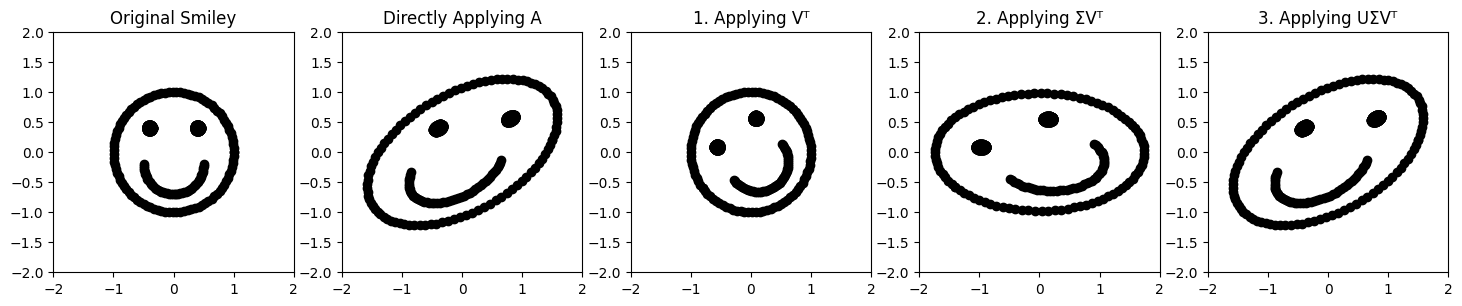

In [3]:

# --- Arbitrary Matrix (Shear + Scale) ---
A = np.array([[1.5, 0.5],
              [0.2, 1.2]])

# Compute SVD
U, S, Vt = np.linalg.svd(A)
Sigma = np.diag(S)

# --- Smiley Face Point Cloud ---
t = np.linspace(0, 2 * np.pi, 100)
face_x = np.cos(t)
face_y = np.sin(t)
left_eye_x = -0.4 + 0.05 * np.cos(t)
left_eye_y =  0.4 + 0.05 * np.sin(t)
right_eye_x = 0.4 + 0.05 * np.cos(t)
right_eye_y = 0.4 + 0.05 * np.sin(t)
smile_t = np.linspace(0, np.pi, 50)
smile_x = 0.5 * np.cos(smile_t)
smile_y = -0.5 * np.sin(smile_t) - 0.2

points = np.vstack((
    np.column_stack((face_x, face_y)),
    np.column_stack((left_eye_x, left_eye_y)),
    np.column_stack((right_eye_x, right_eye_y)),
    np.column_stack((smile_x, smile_y))
))

# --- Apply Transformations ---
points_A = (A @ points.T).T
points_Vt = (Vt @ points.T).T
points_Sigma = (Sigma @ points_Vt.T).T
points_USigma = (U @ points_Sigma.T).T

# --- Plotting ---
fig, axes = plt.subplots(1, 5, figsize=(18, 6))

titles = ["Original Smiley", "Directly Applying A", "1. Applying Vᵀ", "2. Applying ΣVᵀ", "3. Applying UΣVᵀ"]
point_sets = [points, points_A, points_Vt, points_Sigma, points_USigma]

for ax, title, pts in zip(axes, titles, point_sets):
    ax.scatter(pts[:, 0], pts[:, 1], color='black')
    ax.set_title(title)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect('equal')
    ax.grid(False)

plt.show()


## Image Compression With the SVD:

-------------------
Given a matrix $A$, we can take the SVD to yield:

$$ A = U\Sigma V^T$$ 
Where the diagonal elements $(\sigma_1,\sigma_2,...,\sigma_n)$ are ordered in terms of their energy, we can "approximate" the action of the matrix by considering only the first $k$ singular values of our choosing.

We would call this a "rank k" approximation.

**Image Compression** 

-------------------
Lets consider how we might use this low rank approximation for the purposes of image compression. If an image is a large $m \times n$ array, one *could* conceive of it as being a matrix...!

Now, what might the low rank approximation of this image "matrix" look like?

In [4]:
# --- Load Your JPG Image ---
image = Image.open('./Data/Beltrami.jpg').convert('L')  # 'L' converts to grayscale
image_np = np.array(image) / 255.0  # Normalize to [0, 1] for display

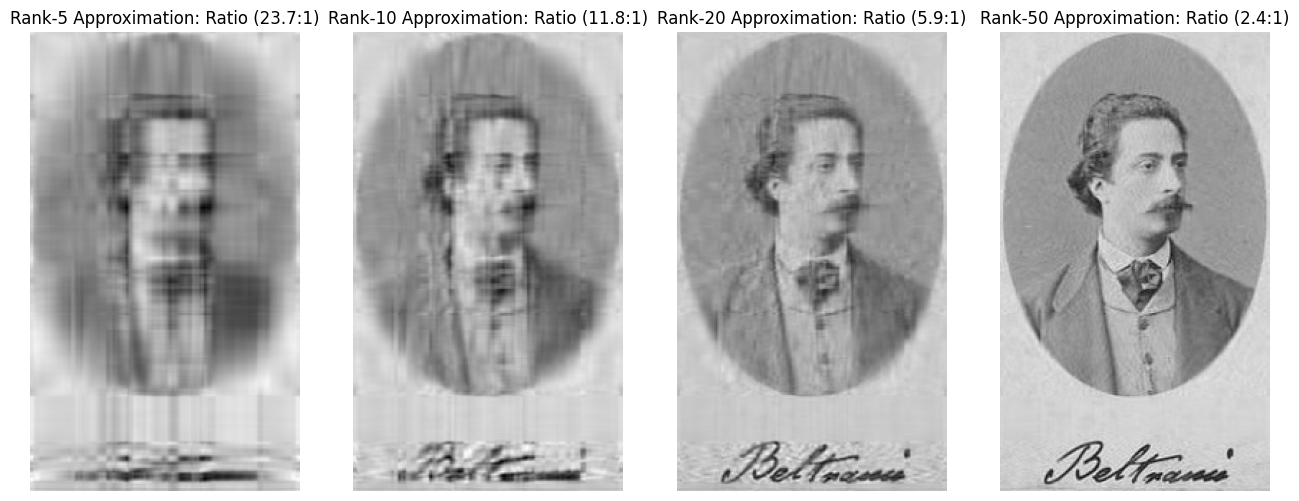

In [7]:
# --- Compute SVD ---
U, S, Vt = np.linalg.svd(image_np, full_matrices=False)

# --- Function to Reconstruct Image with Rank-k Approximation ---
def low_rank_approx(U, S, Vt, k):
    return (U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :])

# --- Plot Original and Approximations ---
fig, axes = plt.subplots(1, 4, figsize=(16, 6))
ranks = [5, 10, 20, 50]

for ax, k in zip(axes, ranks):
    A_k = low_rank_approx(U, S, Vt, k)
    ax.imshow(A_k, cmap='gray')
    compression_ratio = (188*320) / (k*(188+320)) #(Compression ratio where 188x320 is original dimensions and k the rank)
    ax.set_title(f'Rank-{k} Approximation: Ratio ({compression_ratio:.1f}:1)')
    ax.axis('off')

plt.show()